In [34]:
import pandas as pd
import matplotlib.pyplot as plt
path = r"C:\Users\Usuario\Desktop\Master data science\Presentation and visualization\accidents_bcn_2019_2025.csv"
df = pd.read_csv(path, encoding='utf-8', low_memory=False)
df.head()

,numero_expedient,codi_districte,nom_districte,nom_barri,nom_carrer,nk_any,mes_any,nom_mes,dia_mes,hora_dia,...,latitud,fichero_origen,es_causa_vianant,fecha,dia_semana,fin_de_semana,franja_horaria,total_lesionados,gravedad,accidente_con_victimas
0,2019S000001,5.0,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,Diagonal / Augusta,2019,1,Gener,1,1,...,41.395744,2019_accidents_gu_bcn.csv,False,2019-01-01,Tuesday,Laborable,Madrugada (00-06h),1,Grave,True
1,2019S000002,9.0,Sant Andreu,el Congrés i els Indians,Felip II / Congrés Eucarístic,2019,1,Gener,1,4,...,41.425361,2019_accidents_gu_bcn.csv,False,2019-01-01,Tuesday,Laborable,Madrugada (00-06h),1,Leve,True
2,2019S000003,10.0,Sant Martí,el Parc i la Llacuna del Poblenou,Pallars,2019,1,Gener,1,5,...,41.396887,2019_accidents_gu_bcn.csv,True,2019-01-01,Tuesday,Laborable,Madrugada (00-06h),1,Leve,True
3,2019S000004,6.0,Gràcia,el Camp d'en Grassot i Gràcia Nova,Taxdirt / Nogués,2019,1,Gener,1,8,...,41.408772,2019_accidents_gu_bcn.csv,False,2019-01-01,Tuesday,Laborable,Manana (06-12h),1,Leve,True
4,2019S000005,2.0,Eixample,la Dreta de l'Eixample,Consell de Cent / Girona,2019,1,Gener,1,12,...,41.394884,2019_accidents_gu_bcn.csv,False,2019-01-01,Tuesday,Laborable,Tarde (12-18h),2,Leve,True


In [35]:
import requests
import geopandas as gpd
from shapely import wkt

url = "https://opendata-ajuntament.barcelona.cat/resources/bcn/EstadisticaUnitatsAdministratives/BarcelonaCiutat_Districtes.json"

response = requests.get(url)
data = response.json()

districts = gpd.GeoDataFrame(data)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16496\2726690836.py:6: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  districts["geometry"] = districts["geometria_etrs89"].apply(wkt.loads)


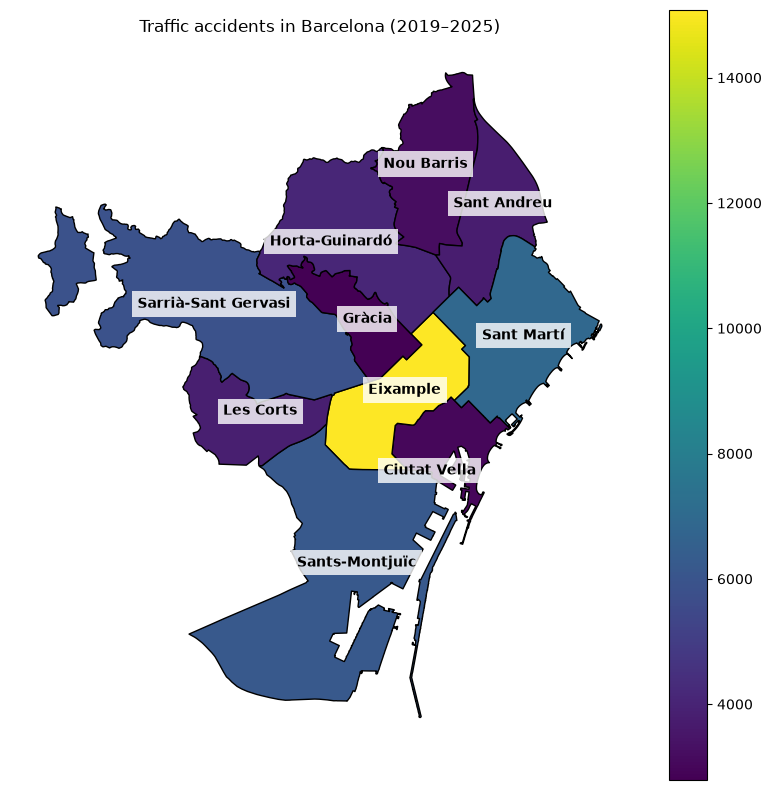

In [36]:
# Count accidents
accidents = df['nom_districte'].value_counts().reset_index()
accidents.columns = ['nom_districte', 'accidents']

# Map
districts["geometry"] = districts["geometria_etrs89"].apply(wkt.loads)
districts = gpd.GeoDataFrame(
    districts,
    geometry="geometry"
)

# Combine map + accident counts
map_data = districts.merge(
    accidents,
    on='nom_districte'
)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the districts
map_data.plot(
    column="accidents",
    legend=True,
    edgecolor="black",
    ax=ax
)

# Add district names
for idx, row in map_data.iterrows():
    point = row.geometry.representative_point()
    
    ax.annotate(
        row["nom_districte"],
        xy=(point.x, point.y),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

ax.set_title("Traffic accidents in Barcelona (2019–2025)")
ax.axis("off")

plt.show()